In [ ]:
import floodlight as floodlight
import pandas as pd
import numpy as np
import os

# Core floodlight objects for working with tracking data
from floodlight import XY, Pitch

# DFL-specific I/O: reads Bundesliga XML tracking and event files
import floodlight.io.dfl as dfl

# Floodlight models for computing kinematic properties from position data
from floodlight.models.kinematics import DistanceModel, VelocityModel, AccelerationModel

# Signal processing: Butterworth low-pass filter for smoothing noisy tracking data
from floodlight.transforms.filter import butterworth_lowpass

import matplotlib.pyplot as plt

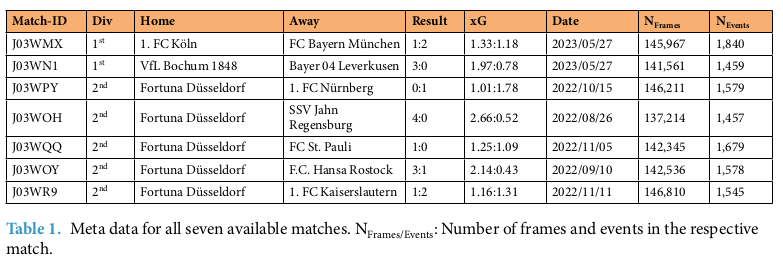

## Loading Data

The code below loads the match data from the DFL Open Data dataset (Bundesliga 22/23 season).
We use the `floodlight` library's built-in DFL reader, which parses the raw XML files and
returns them in floodlight's standardized data format.

First, select a match ID from the list above — each ID corresponds to one Bundesliga match.
The default here is the Bochum vs. Leverkusen match (`J03WMX`).

In [ ]:
# Root directory containing all DFL Open Data XML files
DATA_DIR = '/home/max/drive/data/openData2223/'

# Available match IDs — each corresponds to one Bundesliga match from the 22/23 season
ls_match_ids = ['J03WMX', 'J03WN1', 'J03WPY', 'J03WOH', 'J03WQQ', 'J03WOY', 'J03WR9']

In [3]:
match_id = 'J03WMX'

In [ ]:
# Build file paths by scanning the data directory for files that contain the match ID
# and the relevant keyword ('positions', 'events', 'matchinformation')
path_positions = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'positions' in x][0])
path_events    = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'events' in x][0])
path_info      = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'matchinformation' in x][0])

In [ ]:
# Load position tracking data from the DFL XML files.
# Returns:
#   xy          — nested dict {half: {team: XY object}} with per-frame x/y positions
#   possession  — nested dict {half: array} with per-frame possession indicator (1=Home, 2=Away)
#   ballstatus  — nested dict {half: array} with per-frame ball status (1=active, 0=dead)
#   teamsheets  — dict {team: Teamsheet object} mapping player metadata to xID column indices
#   pitch       — Pitch object describing the playing field dimensions
xy, possession, ballstatus, teamsheets, pitch = dfl.read_position_data_xml(
    path_positions, path_info, teamsheet_home=None, teamsheet_away=None
)

In [ ]:
# Load match event data (goals, fouls, substitutions, etc.)
# The events are not used for HI run extraction, but can be useful for
# cross-referencing runs with specific match situations.
events, teamsheets, pitch = dfl.read_event_data_xml(path_events, path_info)

The **floodlight** library uses a consistent, nested data structure for football tracking data.
Here is what each returned object contains:

- **`xy`** — The main position tracking data. It is a nested dictionary organized first by half
  (`'firstHalf'`, `'secondHalf'`) and then by team (`'Home'`, `'Away'`, `'Ball'`).
  Each entry is an `XY` object whose `.xy` attribute is a 2D NumPy array of shape
  `(n_frames, 2 * n_players)`. Columns come in pairs: columns `[0, 1]` are the x/y
  coordinates of player 0 (index `xID=0`), columns `[2, 3]` are player 1, and so on.
  The coordinate system is centered on the pitch midpoint (in metres).

- **`possession`** — A 1D NumPy array (one value per frame) encoding ball possession:
  `1` = Home team, `2` = Away team, `0` = no clear possession.

- **`ballstatus`** — A 1D NumPy array indicating whether the ball is in active play
  (`1` = active, `0` = dead ball / set piece).

- **`teamsheets`** — A dictionary with `'Home'` and `'Away'` keys. Each value is a
  `Teamsheet` object whose `.teamsheet` attribute is a DataFrame containing player metadata:
  jersey number (`jID`), name (`player`), position (`position`), and crucially the
  column index `xID` that maps each player to their columns in the `xy` arrays.

- **`pitch`** — Describes the pitch dimensions, coordinate system, and sport type.

The nested `xy` structure requires a little getting used to, but all downstream analyses
in floodlight are built around this format, so it's best to work with it directly.

In [ ]:
# Set the sport so floodlight uses football-specific pitch conventions
pitch.sport = "football"

# Unpack the nested xy dictionary into named variables for convenience.
# Each XY object's .xy attribute is a (n_frames × 2*n_players) NumPy array.
# Column layout: [x_p0, y_p0, x_p1, y_p1, ..., x_pN, y_pN]
# To get all x-coordinates for all players: xy_data[:, ::2]
# To get all y-coordinates for all players: xy_data[:, 1::2]
# To get coordinates for player with xID=k:  xy_data[:, [2*k, 2*k+1]]
xy_firsthalf_home = xy['firstHalf']['Home']
xy_firsthalf_away = xy['firstHalf']['Away']

xy_secondhalf_home = xy['secondHalf']['Home']
xy_secondhalf_away = xy['secondHalf']['Away']

# Unpack possession arrays (one value per frame: 1=Home, 2=Away, 0=unclear)
possession_firsthalf  = possession['firstHalf']
possession_secondhalf = possession['secondHalf']

## Computing Velocities

Player velocities are computed from the position data — this is a prerequisite for identifying
high-intensity runs. Floodlight provides a **`VelocityModel`** class that handles this internally.

The workflow follows the standard floodlight pattern:
1. **`.fit(xy_data)`** — feeds the position data into the model.
2. **`.velocity()`** — returns a `Property` object; access the underlying NumPy array via `.property`.

The resulting array has the same shape as the `xy` array: `(n_frames, n_players)`.
We store the velocity arrays for all halves and teams in a nested dictionary
(`velocity_dict`) that mirrors the structure of the `xy` object.

### Get Velocities for All Halves and Teams

In [ ]:
# VelocityModel computes instantaneous speed (in m/s) from positional differences between frames.
# The standard floodlight workflow is: instantiate → fit(xy) → call .velocity().property
# The output array has shape (n_frames, n_players), matching the xy array layout.
vm = VelocityModel()

# Pre-allocate the nested dictionary to store velocity arrays for each half and team
velocity_dict = {
    'firstHalf' : {'Home': None, 'Away': None},
    'secondHalf' : {'Home': None, 'Away': None}
}

vm.fit(xy_firsthalf_home)
velocity_dict['firstHalf']['Home'] = vm.velocity().property

vm.fit(xy_firsthalf_away)
velocity_dict['firstHalf']['Away'] = vm.velocity().property

vm.fit(xy_secondhalf_home)
velocity_dict['secondHalf']['Home'] = vm.velocity().property

vm.fit(xy_secondhalf_away)
velocity_dict['secondHalf']['Away'] = vm.velocity().property

In [ ]:
# Raw tracking data contains noise (GPS jitter, interpolation artefacts), which causes
# the computed velocity to spike unrealistically. A Butterworth low-pass filter smooths
# the position data before computing derivatives to get cleaner velocity/acceleration signals.
#
# Wn=0.5 sets the cut-off frequency (as a fraction of the Nyquist frequency).
# order=1 is a gentle first-order filter — higher order = steeper roll-off but more phase shift.
# remove_short_seqs=True drops short segments of valid data that are too brief to filter reliably.
xy_filt = butterworth_lowpass(xy_firsthalf_home, remove_short_seqs=True, Wn=0.5, order=1)

vm = VelocityModel()
am = AccelerationModel()

vm.fit(xy_filt)
velocity_1st_home = vm.velocity().property      # shape: (n_frames, n_players), units: m/s

am.fit(xy_filt)
acceleration_1st_home = am.acceleration().property  # shape: (n_frames, n_players), units: m/s²

In [ ]:
def moving_average(a, n=3):
    """Compute a causal (trailing) moving average over a 1D array using cumulative sums."""
    ret = np.nancumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

# Example: smooth the velocity signal for player xID=9 with a 20-frame (0.8 s) window.
# Note: the extract_runs_for_player function uses pandas .rolling() with center=True,
# which is a centered (non-causal) window — slightly different from this trailing average.
vel_rolling = moving_average(velocity_1st_home[:, 9], n=20)

In [ ]:
# Compare raw vs. filtered velocity for a single player over the first 5 minutes.
# This is useful for understanding how much the Butterworth filter smooths the signal.
# Uncomment the other plot lines to overlay the rolling average or acceleration.
MINS = 5
FRAMES = MINS * 60 * 25  # 25 fps → 7500 frames per 5 minutes

plt.figure(figsize=(20, 10))
plt.plot(velocity_dict['firstHalf']['Home'][:FRAMES, 9], label='Raw velocity (VelocityModel, no filter)')
plt.plot(velocity_1st_home[:FRAMES, 9], label='Filtered velocity (Butterworth)')
# plt.plot(vel_rolling[:FRAMES], label='Rolling average (20-frame window)')
# plt.plot(acceleration_1st_home[:FRAMES, 9], label='Acceleration')
plt.xlabel('Frame')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity comparison for player xID=9 — first 5 minutes (first half, home team)')
plt.legend()
plt.tight_layout()

## Get Running Distances for All Players

In [ ]:
# Compute total distance covered per player per half, using a Butterworth-filtered
# position signal and floodlight's DistanceModel.
# Note: xy_all must be defined as {half: {team: XY}} before running this cell.
ls_dfs_distance = []
for half, teams in xy_all.items():
    for team, xy_data in teams.items():
        # Filter the position data before computing distances to reduce noise
        xy_f = butterworth_lowpass(xy_data, remove_short_seqs=True, Wn=0.5, order=1)

        dm = DistanceModel()
        dm.fit(xy_f)

        df_players = teamsheets[team].teamsheet.copy()
        # distance_covered() returns a (n_frames × n_players) array; sum over frames (axis=0)
        df_players['distance_covered'] = np.nansum(dm.distance_covered().property, axis=0)
        df_players['location'] = team
        df_players['half'] = half
        ls_dfs_distance.append(df_players)

In [ ]:
df_distances = pd.concat(ls_dfs_distance).groupby(['location', 'team', 'player']).agg(
    total_distance_m=pd.NamedAgg(column='distance_covered', aggfunc='sum'),
    position=pd.NamedAgg(column='position', aggfunc='first'),
    jID=pd.NamedAgg(column='jID', aggfunc='first'),
)

## Extract High-Intensity (HI) Runs

### Helper Functions: Timecode Conversion

Tracking data is indexed by **frame number** (at 25 fps). The functions below convert
frame numbers to human-readable match timestamps (e.g., `"23:45"`), which makes it much
easier to locate specific runs when reviewing match video.

In [83]:
def sec_to_minute(seconds):
    minutes = seconds // 60
    seconds = seconds % 60
    return f"{int(minutes)}:{int(seconds):02d}"

def frame_to_minute(frame, frate=25):
    return sec_to_minute(frame / frate) 

### Functions for Extracting High-Intensity Runs

These functions segment the continuous velocity time series into discrete runs.

- **`extract_runs_for_player`**: Extracts HI runs for a single player. It applies a
  rolling average to smooth the raw velocity signal, then detects contiguous periods where
  the player's speed exceeds the threshold velocity. Each such period that is long enough
  (≥ `min_duration_frames`) becomes one "run", stored as a DataFrame with per-frame
  x/y coordinates, raw velocity, and ball possession.

- **`extract_high_intensity_runs_df`**: Loops over all players (by `xID`) and returns
  a nested dictionary: `{player_xID: {run_id: DataFrame}}`.

- **`summarize_runs_to_dataframe`**: Converts the nested run dictionaries into a flat
  summary DataFrame where each row is one HI run. It joins in player metadata from the
  teamsheet (name, position, jersey number) and computes spatial metrics
  (start/end coordinates, total distance, average speed, duration).

The full extraction pipeline is already end-to-end for HI runs. The next step is to
layer on additional conditions to specifically identify **deep runs** (Tiefenläufe):
- **Direction toward goal** — derivable from start/end x-coordinates; consider whether
  the full trajectory is needed for robustness.
- **Movement angle** — the formal definition requires 45–135° relative to the goal direction.
- **Minimum distance** — runs shorter than 3 m should be excluded.
- **Opponents beaten** — how many defenders were bypassed requires going back to the raw
  position data to compute at each frame.
- **Standard situation exclusions** — runs within 6 s of a set piece should be filtered out
  (use the `ballstatus` array to detect dead-ball phases).

In [84]:
# Constants
HIGH_INTENSITY_THRESHOLD = 21 / 3.6  # 21 km/h in m/s
N_PLAYERS = 20

def extract_runs_for_player(player_id, velocities, tracking_data, possession,
                            threshold=HIGH_INTENSITY_THRESHOLD,
                            rolling_window=5,
                            min_duration_frames=25):
    """Extract high-intensity runs for a single player with smoothing and duration threshold."""
    player_velocity = velocities[:, player_id]

    # Apply centered rolling average
    smoothed_velocity = pd.Series(player_velocity).rolling(
        window=rolling_window, center=True, min_periods=1).mean().to_numpy()

    is_high_intensity = smoothed_velocity > threshold

    # Detect transitions
    diff = np.diff(is_high_intensity.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    runs = {}
    for i, (start, end) in enumerate(zip(starts, ends)):
        if end - start >= min_duration_frames:
            frames = np.arange(start, end)
            x = tracking_data[start:end, ::2][:, player_id]
            y = tracking_data[start:end, 1::2][:, player_id]
            v = player_velocity[start:end]  # use original velocity
            p = possession[start:end]

            df_run = pd.DataFrame({
                "frame": frames,
                "x": x,
                "y": y,
                "velocity": v,
                "possession": p,
            })
            runs[i] = df_run

    return runs


In [13]:
def extract_high_intensity_runs_df(velocities, tracking_data, possession,
                                   threshold=HIGH_INTENSITY_THRESHOLD,
                                   rolling_window=5,
                                   min_duration_frames=25):
    """Extract high-intensity runs for all players."""
    result = {}
    for player_id in range(N_PLAYERS):
        result[player_id] = extract_runs_for_player(
            player_id, velocities, tracking_data, possession,
            threshold=threshold,
            rolling_window=rolling_window,
            min_duration_frames=min_duration_frames)
    return result

In [14]:
def summarize_runs_to_dataframe(runs_dict, teamsheet, framerate=25):
    """Converts high-intensity run data to a summary DataFrame."""
    rows = []

    for xID, runs in runs_dict.items():
        if not isinstance(runs, dict):
            continue  # Skip non-run entries (e.g., if metadata is mixed in)

        # Lookup player info
        player_info = teamsheet.loc[teamsheet['xID'] == xID]
        if player_info.empty:
            continue  # Skip if no matching player

        player_name = player_info['player'].values[0]
        position = player_info['position'].values[0]
        team_name = player_info['team'].values[0]
        jersey_id = player_info['jID'].values[0]

        for run_id, df in runs.items():
            start_frame = df['frame'].iloc[0]
            end_frame = df['frame'].iloc[-1]
            possession = "Home" if df['possession'].iloc[0] == 1 else "Away"
            
            x_start, y_start = df[['x', 'y']].iloc[0]
            x_end, y_end = df[['x', 'y']].iloc[-1]
            avg_velocity_kmh = df['velocity'].mean() * 3.6
            duration_s = len(df) / framerate
            # Distance using cumulative Euclidean distance
            deltas = df[['x', 'y']].diff().dropna()
            distance_m = np.sqrt((deltas**2).sum(axis=1)).sum()

            rows.append({
                "start_frame": start_frame,
                "end_frame": end_frame,
                #"start_timecode": start_timecode,
                "xID": xID,
                "player": player_name,
                "position": position,
                "team": team_name,
                "possession" : possession,
                "jID": jersey_id,
                "x_start": x_start,
                "y_start": y_start,
                "x_end": x_end,
                "y_end": y_end,
                "avg_velocity_kmh": avg_velocity_kmh,
                "distance_m": distance_m,
                "duration_s": duration_s
            })

    return pd.DataFrame(rows)


## Extract HI Run Summaries for all Runs in Match

In [ ]:
ls_dfs = []

for half in ['firstHalf', 'secondHalf']:
    for team in ['Home', 'Away']:

        # Extract discrete HI runs from the velocity time series for all players in this team/half
        runs_dict = extract_high_intensity_runs_df(
            velocity_dict[half][team],       # (n_frames × n_players) velocity array
            xy[half][team].xy,               # (n_frames × 2*n_players) position array
            possession[half],                # (n_frames,) possession indicator
            threshold=HIGH_INTENSITY_THRESHOLD,
            rolling_window=5,                # 5-frame (0.2 s) centered smoothing window
            min_duration_frames=25           # minimum run length: 25 frames = 1 second at 25 fps
        )

        # Convert the nested dict {xID: {run_id: DataFrame}} into a flat summary DataFrame
        summary_df = summarize_runs_to_dataframe(
            runs_dict, teamsheets[team].teamsheet, framerate=25)

        summary_df['half'] = half
        summary_df['team'] = team

        # Convert frame numbers to match timestamps.
        # For second-half frames, add 67500 frames (= 45 min × 60 s × 25 fps) as offset
        # so that the timecode reflects real match time rather than half-relative time.
        summary_df['start_timecode'] = summary_df.apply(
            lambda x: frame_to_minute(x['start_frame']) if x.half == "firstHalf"
                      else frame_to_minute(x['start_frame'] + 67500), axis=1)
        summary_df['end_timecode'] = summary_df.apply(
            lambda x: frame_to_minute(x['end_frame']) if x.half == "firstHalf"
                      else frame_to_minute(x['end_frame'] + 67500), axis=1)

        ls_dfs.append(summary_df)

# Combine all halves and teams into one DataFrame; drop any zero-distance artefacts
df_hi_runs = pd.concat(ls_dfs, ignore_index=True)
df_hi_runs = df_hi_runs[df_hi_runs.distance_m > 0]

In [27]:
df_hi_runs['team'].value_counts()

team
Away    310
Home    295
Name: count, dtype: int64

<Axes: >

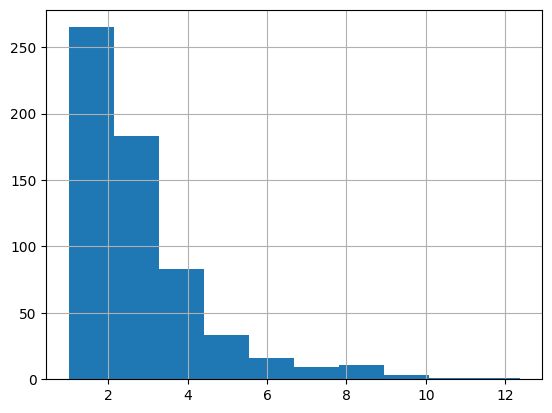

In [28]:
df_hi_runs['duration_s'].hist()

## Filter: Only HI Runs by the Ball-Possessing Team

As a first condition for deep runs, we keep only high-intensity runs made by players
**from the team currently in possession of the ball**. The `possession` column in the
DataFrame records which team had the ball at the start of each run (`'Home'` or `'Away'`),
and we compare it directly to the `team` column.

This halves the candidate pool roughly in half (as expected — only one team is in
possession at a time).

You can apply similar logic to add further filters for deep runs, for example:
- **Run direction** — compare `x_start` and `x_end` to check whether the player moved
  toward the opponent's goal. Remember that teams switch sides at half-time, so the
  sign convention flips.
- **Movement angle** — use the full trajectory (from the per-frame run DataFrames) to
  compute the dominant movement angle and enforce the 45–135° requirement.
- **Minimum distance** — add `df_hi_runs_filtered[df_hi_runs_filtered.distance_m > 3]`.
- **Standard situation exclusions** — cross-reference run start frames with dead-ball
  phases from the `ballstatus` array, and discard runs starting within 6 s (150 frames)
  of a set piece restart.

In [ ]:
# Keep only runs where the running player's team also had ball possession at the run start.
# This is a core condition of the deep run definition: the player must be on the attacking team.
# The 'team' column is 'Home'/'Away' (from the loop), and 'possession' is derived from the
# possession array (1→'Home', 2→'Away'), so a simple equality check suffices.
df_hi_runs_filtered = df_hi_runs[df_hi_runs.team == df_hi_runs.possession].sort_values(by="start_frame")

In [31]:
df_hi_runs_filtered['team'].value_counts()

team
Home    154
Away    133
Name: count, dtype: int64

In [32]:
df_hi_runs_filtered.round(2)

,start_frame,end_frame,xID,player,position,team,possession,jID,x_start,y_start,x_end,y_end,avg_velocity_kmh,distance_m,duration_s,half,start_timecode,end_timecode
94,188,235,9,Shinta Appelkamp,ZO,Home,Home,23,-18.89,-12.29,-30.79,-13.98,22.98,12.03,1.92,firstHalf,0:07,0:09
615,1404,1433,6,M. Møller Dæhli,OLM,Away,Away,10,-13.24,-22.26,-12.50,-18.37,21.72,3.97,1.20,secondHalf,45:56,45:57
153,1498,1528,16,M. Karbownik,LV,Home,Home,8,4.53,-26.24,-2.78,-27.46,22.21,7.42,1.24,firstHalf,0:59,1:01
234,1568,1616,10,Kwadwo Duah,STR,Away,Away,23,14.86,-15.27,22.17,-24.90,23.09,12.34,1.96,firstHalf,1:02,1:04
332,1642,1673,16,J. Castrop,ORM,Away,Away,17,15.14,-17.75,22.02,-13.84,23.03,7.95,1.28,firstHalf,1:05,1:06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,74036,74140,12,Kristoffer Peterson,ORM,Home,Home,7,1.86,-5.40,27.49,-7.38,24.15,27.44,4.20,secondHalf,94:21,94:25
488,74037,74098,13,C. Klarer,IVL,Home,Home,5,15.01,8.52,27.63,7.50,21.78,12.75,2.48,secondHalf,94:21,94:23
408,74076,74140,8,N. Gavory,LV,Home,Home,34,-1.31,21.33,13.46,20.28,23.83,14.83,2.60,secondHalf,94:23,94:25
470,75130,75160,12,Kristoffer Peterson,ORM,Home,Home,7,43.67,3.04,42.30,3.64,21.94,1.51,1.24,secondHalf,95:05,95:06


In [47]:
df_hi_runs_filtered.sort_values(by="absolute_start_frame", ascending=True)

,start_frame,end_frame,xID,player,position,team,possession,jID,x_start,y_start,x_end,y_end,avg_velocity_kmh,distance_m,duration_s,half,start_timecode,end_timecode,absolute_start_frame,absolute_end_frame
94,188,235,9,Shinta Appelkamp,ZO,Home,Home,23,-18.89,-12.29,-30.79,-13.98,22.976371,12.026938,1.92,firstHalf,0:07,0:09,4021.0,4068.0
153,1498,1528,16,M. Karbownik,LV,Home,Home,8,4.53,-26.24,-2.78,-27.46,22.205890,7.416047,1.24,firstHalf,0:59,1:01,5331.0,5361.0
234,1568,1616,10,Kwadwo Duah,STR,Away,Away,23,14.86,-15.27,22.17,-24.90,23.089647,12.335635,1.96,firstHalf,1:02,1:04,5401.0,5449.0
332,1642,1673,16,J. Castrop,ORM,Away,Away,17,15.14,-17.75,22.02,-13.84,23.028730,7.954136,1.28,firstHalf,1:05,1:06,5475.0,5506.0
0,1811,1894,2,Matthias Zimmermann,RV,Home,Home,25,44.51,4.68,50.27,27.23,26.196091,24.224546,3.36,firstHalf,1:12,1:15,5644.0,5727.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,74036,74140,12,Kristoffer Peterson,ORM,Home,Home,7,1.86,-5.40,27.49,-7.38,24.149756,27.437630,4.20,secondHalf,94:21,94:25,170885.0,170989.0
488,74037,74098,13,C. Klarer,IVL,Home,Home,5,15.01,8.52,27.63,7.50,21.777893,12.750481,2.48,secondHalf,94:21,94:23,170886.0,170947.0
408,74076,74140,8,N. Gavory,LV,Home,Home,34,-1.31,21.33,13.46,20.28,23.834760,14.831776,2.60,secondHalf,94:23,94:25,170925.0,170989.0
470,75130,75160,12,Kristoffer Peterson,ORM,Home,Home,7,43.67,3.04,42.30,3.64,21.939398,1.508801,1.24,secondHalf,95:05,95:06,171979.0,172009.0
